In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Salary_dataset - Salary_dataset.csv')
print("loaded")

loaded


In [ ]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [ ]:
df.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583
26,26,9.6,116970
27,27,9.7,112636
28,28,10.4,122392
29,29,10.6,121873


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
df.isnull()

,Unnamed: 0,YearsExperience,Salary
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df.shape

(30, 3)

In [ ]:
df['YearsExperience'] = df['YearsExperience'].apply(np.floor)
df.head(30)

,Unnamed: 0,YearsExperience,Salary
0,0,1.0,39344
1,1,1.0,46206
2,2,1.0,37732
3,3,2.0,43526
4,4,2.0,39892
5,5,3.0,56643
6,6,3.0,60151
7,7,3.0,54446
8,8,3.0,64446
9,9,3.0,57190


In [ ]:
#independent variable
x = df.iloc[:,:-1]
x

,Unnamed: 0,YearsExperience
0,0,1.0
1,1,1.0
2,2,1.0
3,3,2.0
4,4,2.0
5,5,3.0
6,6,3.0
7,7,3.0
8,8,3.0
9,9,3.0


In [ ]:
y = df.iloc[:,-1]
y

,Salary
0,39344
1,46206
2,37732
3,43526
4,39892
5,56643
6,60151
7,54446
8,64446
9,57190


In [ ]:
#split the dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#create a model
model = LinearRegression()

In [ ]:
#train the model
model.fit(x_train, y_train)
print("Model Trained")


Model Trained


In [ ]:
#generate predictions for training and testing datasets using the trained model
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("Predictions generated for both training and testing datasets")

Predictions generated for both training and testing datasets


In [ ]:
#evaluation the performance by the model metric
print('Model; Evaluation Metrics')
print('Mean Absolute Error(MAE):', mean_absolute_error(y_train, y_pred_train))
print('Mean_Square Error(MSE):', mean_squared_error(y_train, y_pred_train))
print('Root Mean Square Error(RMSE):', np.sqrt(mean_squared_error(y_train, y_pred_train)))
print('R2 Score:', r2_score(y_train, y_pred_train))

Model; Evaluation Metrics
Mean Absolute Error(MAE): 4698.583885696621
Mean_Square Error(MSE): 31989474.392203864
Root Mean Square Error(RMSE): 5655.923831895534
R2 Score: 0.9581458461967761


In [ ]:
#slope
model.coef_

array([ -171.84073839, 10157.34168853])

In [ ]:
#intercept
model.intercept_

np.float64(25827.686894851126)

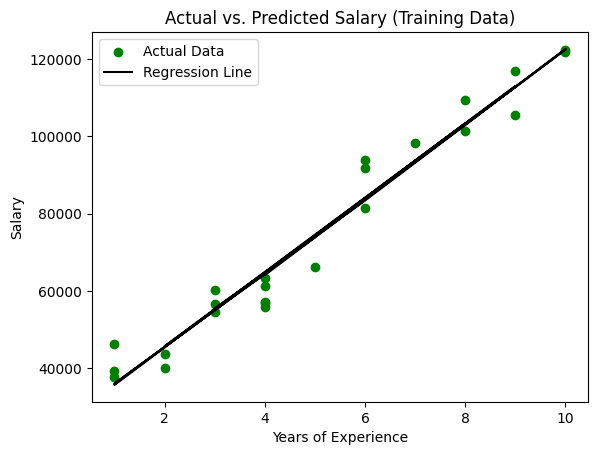

In [ ]:
#plot actual training data points and fitted linear regression line for vizualizartion
plt.scatter(x_train['YearsExperience'], y_train, color='green', label='Actual Data')
plt.plot(x_train['YearsExperience'], y_pred_train, color='black', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs. Predicted Salary (Training Data)')
plt.legend()
plt.show()